# EGFP λ sweep — how the four guidance weights trade off

A 3 × 3 × 3 grid over the **DMS-guide** strategy's guidance weights, everything else held fixed
(EGFP scaffold `4EUL`, Tier-B 5 Å chromophore window with 25 editable positions, `T=10`, `k=10`,
12 trials × 3 iterations). See [`README.md`](README.md) for how the runs were produced.

| axis | values | what it weights |
|---|---|---|
| `λ_ex = λ_em` | 10, 20, 30 | pull toward the target's excitation / emission peaks |
| `λ_bright` | 40, 50, 60 | pull toward the brightness classifier's positive class |
| `λ_edit` | 10, 15, 20 | penalty per position that differs from the scaffold |

27 cells, run for **both campaign targets**, which bracket the difficulty and are worth reading
separately rather than pooled:

- **mOrange** — the far shift: ~30 % sequence identity to EGFP, `(488, 507) → (548, 562)` nm, and the
  untouched scaffold starts ~57 nm off target.
- **EBFP** — close to EGFP in *sequence* but the *larger* spectral jump, `(488, 507) → (380, 440)` nm,
  so the scaffold starts ~88 nm off target.

Because their scaffold errors differ by ~30 nm, **every figure is drawn once per target with its own
colour scale**: comparing a cell's colour across targets is meaningless, comparing its rank is not.

Every term is **z-scored across the k=10 candidates at each position before its λ is applied**
(`fpdesign/campaign.py::_zc`) and the sum is divided by `T=10` inside the softmax, so these weights
are in units of "standard deviations of that term", which is why the useful range is 10–60 rather
than ~1. The four λs are read from the **folder name**, the only complete record of them (the engine
writes `lam_ex`/`lam_em`/`lam_bright` columns but has no `lam_edit` column).

## What is plotted

Final-round designs of the first 12 trajectories per cell, on four families of heatmap:

- **mutations** — how far the design walked from EGFP (`n_mut`, and % identity).
- **peak error** — `|Δex|`, `|Δem|` and their mean `peak_err`, in nm. The untouched scaffold's own error
  is annotated on each figure; that is the number a setting has to beat to have done anything.
- **in-distribution (ID) hits** — designs whose 1-NN distance into the 40k GFP-DMS embedding manifold
  is within that reference set's own p99. Outside it, the brightness classifier is extrapolating and
  its call should not be trusted.
- **brightness hits** — designs with a positive `cnn-max-d2` logit (val AUROC 0.982), plus the
  **joint gate** (ID *and* bright), which is what actually feeds a wet-lab shortlist.

> **No oracle here.** Peak error comes from the same surrogate that guided the search (train MAE
> 5.2 nm) and brightness from the same classifier used as a guidance term, so both are *in-sample and
> optimistic*. These heatmaps compare **settings against each other**, which is valid; they do not
> predict absolute wet-lab success. The ID gate is the honesty check on the brightness column.

Two data caveats: the `ppl` column is deliberately blank (it cost more than a design iteration and
sat flat at 16.2–16.7 everywhere), and five cells (three mOrange, two EBFP) were imported from earlier
identical runs that hold 24/48/96 trials, so everything is truncated to the first 12 — exact, not a
subsample, because the engine seeds RNG per trial.

In [1]:
# Score every sweep cell: mutations, per-peak error, in-distribution and brightness gates.
# Emits TWO tables, deliberately on different footings:
#   S = one row per (cell, target) over the FINAL round of the first TRIALS trials. Equal depth
#       everywhere, so the heatmaps compare settings fairly -- this is what the grid is for.
#   D = one row per DESIGN over every iteration (round >= 1) of every trial the CSV holds, deduped
#       by sequence. This is the pool a shortlist actually draws from, and it is what the scatter
#       plots show. Three cells were run 24-96 trials deep, so pools are unequal by design here;
#       best-of-pool improves with pool size, so read the scatters as "what is in hand", not as a
#       fair per-trial comparison of settings.
# GPU work is cached; set RESCORE=True (or delete the CSVs) to recompute.
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRIALS = 12        # depth the CELL table is truncated to; 0 = every trial (scatters ignore this)
RESCORE = False    # True = ignore the cache and re-score every cell from scratch

HERE = Path.cwd() if (Path.cwd() / "designs").exists() else Path.cwd() / "design-campaign-EGFP/lambda_sweep"
REPO = next(b for b in HERE.parents if (b / "fpdesign").exists())
FIGDIR = HERE / "figures"; FIGDIR.mkdir(exist_ok=True)
CACHE = HERE / "sweep_metrics.csv"          # per cell
DCACHE = HERE / "sweep_designs.csv"         # per design
CELL_RE = re.compile(r"lam-ex(?P<ex>[\d.]+)_lam-em(?P<em>[\d.]+)"
                     r"_lam-bright(?P<bright>[\d.]+)_lam-edit(?P<edit>[\d.]+)")
print("sweep:", HERE, "| repo:", REPO)


def score_cells(done=None):
    """The expensive pass -- ESM-2 embeddings + brightness classifier. Returns (per-cell, per-design).

    ``done`` is a set of (lam_p, lam_b, lam_e, target, trials_avail) keys already cached; those cells
    are skipped, so re-running while the sweep is still filling in cells only scores the new ones (and
    a cell whose CSV has since grown re-scores, because trials_avail is part of the key)."""
    done = done or set()
    todo = []
    for folder in sorted((HERE / "designs").glob("lam-ex*")):
        m = CELL_RE.fullmatch(folder.name)
        if not m:
            print("  skip unrecognized folder", folder.name); continue
        lam = {k: float(v) for k, v in m.groupdict().items()}
        for csv in sorted(folder.glob("design_EGFP-*.csv")):
            d = pd.read_csv(csv)
            key = (lam["ex"], lam["bright"], lam["edit"], csv.stem.split("-", 1)[1], d.trial.nunique())
            if key not in done:
                todo.append((folder, csv, lam, d))
    if not todo:
        print(f"nothing new to score ({len(done)} cells cached)")
        return pd.DataFrame(), pd.DataFrame()

    import torch
    from sklearn.neighbors import NearestNeighbors
    sys.path.insert(0, str(REPO))
    from fpdesign import peak_models as pm
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ID reference: 1-NN distance in the 40k GFP-DMS max-pool embedding space. The cut is the
    # reference set's OWN p99 self-NN distance, i.e. "no further from a real DMS variant than the
    # DMS variants are from each other".
    z = np.load(REPO / "GFP_DMS" / "DMS_data" / "esm_maxpool_4scaffold_10k.npz", allow_pickle=True)
    mp = z["mp"]; mu, sd = mp.mean(0), mp.std(0) + 1e-6; Z = (mp - mu) / sd
    nn1 = NearestNeighbors(n_neighbors=1).fit(Z)
    p99 = float(np.percentile(NearestNeighbors(n_neighbors=2).fit(Z).kneighbors(Z)[0][:, 1], 99))

    _bb, _bm = pm.load_model(str(REPO / "fpdesign" / "models" / "brightness_cnn-max-d2_40k.pt"), dev, out=1)
    bnet = pm.wrap(_bb, _bm.get("mean", 0.0) or 0.0, _bm.get("std", 1.0) or 1.0, dev)
    print(f"device {dev} | brightness cnn-max-d2 (val AUROC 0.982) | ID cut = p99 {p99:.2f}")

    @torch.no_grad()
    def embed_pool(seqs, bs=64):
        out = []
        for i in range(0, len(seqs), bs):
            H, m = pm.resid_embed(list(seqs[i:i + bs]), dev)
            out.append(pm.masked_pool(H, m, "max").float().cpu().numpy())
        return np.concatenate(out)

    @torch.no_grad()
    def bright_logit(seqs, bs=32):
        out = []
        for i in range(0, len(seqs), bs):
            H, m = pm.resid_embed(list(seqs[i:i + bs]), dev)
            out.append(bnet(H, m).float().cpu().numpy().ravel())
        return np.concatenate(out)

    rows, drows = [], []
    for folder, csv, lam, d in todo:
        n_all = d.trial.nunique()
        tgt = csv.stem.split("-", 1)[1]
        for col, key in (("lam_ex", "ex"), ("lam_em", "em"), ("lam_bright", "bright")):
            got = d[col].dropna().unique() if col in d.columns else []
            if len(got) == 1 and abs(float(got[0]) - lam[key]) > 1e-6:
                print(f"  WARNING {folder.name}: {col}={got[0]} in CSV vs {lam[key]} in folder name")
        r0 = d.iloc[0]
        scaf = r0["scaffold_seq"]
        scaf_err = 0.5 * (abs(r0.scaffold_ex - r0.target_ex) + abs(r0.scaffold_em - r0.target_em))

        # round 0 is the untouched scaffold; every edited sequence lives in rounds 1..iters
        edited = d[d["round"] >= 1]
        uniq = edited["designed_seq"].drop_duplicates().tolist()
        # seq[3:238] reframes to the DMS window the reference embeddings were built on
        dist = dict(zip(uniq, nn1.kneighbors((embed_pool([s[3:238] for s in uniq]) - mu) / sd)[0].ravel()))
        mut = {s: sum(a != b for a, b in zip(s, scaf)) for s in uniq}
        blog = (None if "pred_bright" in edited.columns and edited["pred_bright"].notna().all()
                else dict(zip(uniq, bright_logit(uniq))))   # fall back only if the CSV lacks logits

        def annotate(frame):
            f = frame.copy()
            f["nn_dist"] = f.designed_seq.map(dist)
            f["n_mut"] = f.designed_seq.map(mut)
            f["logit"] = f.pred_bright if blog is None else f.designed_seq.map(blog)
            f["is_id"] = f.nn_dist <= p99
            f["is_bright"] = f.logit > 0
            f["d_ex"] = (f.pred_ex - f.target_ex).abs()
            f["d_em"] = (f.pred_em - f.target_em).abs()
            return f

        # ---- per design: every iteration of every trial, deduped by sequence (the shortlist pool) ----
        g = annotate(edited.drop_duplicates("designed_seq"))
        drows.append(pd.DataFrame(dict(
            target=tgt, lam_p=lam["ex"], lam_b=lam["bright"], lam_e=lam["edit"],
            trial=g.trial.to_numpy(), round=g["round"].to_numpy(), trials_avail=n_all,
            n_mut=g.n_mut.to_numpy(), d_ex=g.d_ex.to_numpy(), d_em=g.d_em.to_numpy(),
            peak_err=g.peak_err.to_numpy(), nn_dist=g.nn_dist.to_numpy(), logit=g.logit.to_numpy(),
            is_id=g.is_id.to_numpy(), is_bright=g.is_bright.to_numpy(), scaf_err=scaf_err)))

        # ---- per cell: final round of the first TRIALS trials, equal depth across the grid ----
        c = annotate(d[(d.trial < TRIALS) if TRIALS else slice(None)]
                     .pipe(lambda f: f[f["round"] == f["round"].max()]))
        rows.append(dict(
            lam_p=lam["ex"], lam_b=lam["bright"], lam_e=lam["edit"],
            target=tgt, n=len(c), trials_avail=n_all, n_designs=len(g),
            d_ex=c.d_ex.mean(), d_em=c.d_em.mean(),
            peak_mean=c.peak_err.mean(), peak_best=c.peak_err.min(), scaf_err=scaf_err,
            n_mut=c.n_mut.mean(), ident=100 * (1 - c.n_mut.mean() / len(scaf)),
            n_id=int(c.is_id.sum()), nn_dist=c.nn_dist.mean(), logit=float(c.logit.mean()),
            n_bright=int(c.is_bright.sum()), n_both=int((c.is_id & c.is_bright).sum()),
        ))
        print(f"  scored {folder.name} {tgt}: {len(g):3d} designs over {n_all} trials "
              f"(cell view: {len(c)} at final round)", flush=True)
    return pd.DataFrame(rows), pd.concat(drows, ignore_index=True)


def stack(old, new):
    parts = [p for p in (old, new) if p is not None and len(p)]
    return pd.concat(parts, ignore_index=True) if len(parts) > 1 else parts[0]


KEY = ["lam_p", "lam_b", "lam_e", "target", "trials_avail"]
reuse = CACHE.exists() and DCACHE.exists() and not RESCORE   # both caches or neither
cachedS = pd.read_csv(CACHE) if reuse else None
cachedD = pd.read_csv(DCACHE) if reuse else None
freshS, freshD = score_cells(done=set(map(tuple, cachedS[KEY].to_numpy())) if reuse else set())
S, D = stack(cachedS, freshS), stack(cachedD, freshD)
if len(freshS):
    S.to_csv(CACHE, index=False); D.to_csv(DCACHE, index=False)
    print(f"wrote {CACHE.name} + {DCACHE.name}  (+{len(freshS)} cells newly scored, "
          f"{0 if cachedS is None else len(cachedS)} reused)")

COUNTS = ["n", "trials_avail", "n_designs", "n_id", "n_bright", "n_both"]
S[COUNTS] = S[COUNTS].astype(int)                       # a round-trip through CSV floats these
for c in ("id", "bright", "both"):                      # counts -> percentages
    S[f"pct_{c}"] = 100 * S[f"n_{c}"] / S["n"]
S["gain"] = S["scaf_err"] - S["peak_mean"]              # nm of error removed vs the raw scaffold
S = S.sort_values(["target", "lam_p", "lam_b", "lam_e"]).reset_index(drop=True)

# far shift first, then the near-in-sequence one; each target keeps its own scaffold reference
TARGETS = [t for t in ("mOrange", "EBFP") if t in set(S.target)] + \
          [t for t in sorted(set(S.target)) if t not in ("mOrange", "EBFP")]
SCAF = S.groupby("target").scaf_err.first().to_dict()
D["gate"] = np.where(D.is_id & D.is_bright, "ID + bright",
                     np.where(D.is_id, "ID only", np.where(D.is_bright, "bright only", "neither")))
for t in TARGETS:
    g, dg = S[S.target == t], D[D.target == t]
    print(f"{t:>8}: {len(g):2d}/27 cells | scaffold {SCAF[t]:.1f} nm off target | "
          f"heatmaps use {g.n.sum():3d} designs (equal depth), scatters use {len(dg):4d}")
S[["target", "lam_p", "lam_b", "lam_e", "n", "n_designs", "n_mut", "d_ex", "d_em", "peak_mean",
   "peak_best", "n_id", "n_bright", "n_both", "logit"]].round(2)

sweep: /home/ubuntu/spectrum-to-fp-design/design-campaign-EGFP/lambda_sweep | repo: /home/ubuntu/spectrum-to-fp-design
nothing new to score (54 cells cached)
 mOrange: 27/27 cells | scaffold 57.5 nm off target | heatmaps use 324 designs (equal depth), scatters use 1351
    EBFP: 27/27 cells | scaffold 87.5 nm off target | heatmaps use 324 designs (equal depth), scatters use 1251


,target,lam_p,lam_b,lam_e,n,n_designs,n_mut,d_ex,d_em,peak_mean,peak_best,n_id,n_bright,n_both,logit
0,EBFP,10.0,40.0,10.0,12,36,9.00,41.38,32.58,36.98,30.41,8,11,8,1.92
1,EBFP,10.0,40.0,15.0,12,35,8.25,38.88,33.83,36.35,19.35,11,8,7,1.35
2,EBFP,10.0,40.0,20.0,12,36,7.08,44.18,36.33,40.25,34.66,12,8,8,1.27
3,EBFP,10.0,50.0,10.0,12,36,9.17,41.72,32.97,37.35,29.68,9,12,9,2.25
4,EBFP,10.0,50.0,15.0,12,36,8.33,39.82,34.69,37.25,29.68,11,9,9,1.86
5,EBFP,10.0,50.0,20.0,12,35,6.83,44.71,36.30,40.50,30.18,10,10,9,1.96
6,EBFP,10.0,60.0,10.0,12,36,9.83,39.33,33.95,36.64,31.10,10,11,10,2.80
7,EBFP,10.0,60.0,15.0,12,36,9.08,44.35,34.92,39.63,32.98,11,11,10,2.47
8,EBFP,10.0,60.0,20.0,12,35,7.50,45.49,36.81,41.15,36.66,11,9,9,1.65
9,EBFP,20.0,40.0,10.0,12,72,11.50,27.38,23.93,25.67,0.27,7,7,5,-0.44


## How to read the heatmaps

The grid is three-dimensional, so each figure is **three panels — one per `λ_ex = λ_em` level** — and
inside a panel **rows are `λ_bright` (60 at the top) and columns are `λ_edit`**. Every cell is one
12-trial run. Each figure is drawn **once per target**.

The colour scale is **shared across the three panels of a figure** (but not across targets), so a cell's
colour is comparable anywhere within one figure, and it is flipped per metric so that **bright yellow
always means "good"** — fewest mutations, smallest error, most hits. The best cell of that target's 27
is outlined in black. Cells that have not been run yet show as `—`.

In [2]:
# Heatmap helper: one panel per lam_ex/em level, rows = lam_bright, cols = lam_edit.
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle

LP = sorted(S.lam_p.unique())                      # panels
LB = sorted(S.lam_b.unique(), reverse=True)        # rows (60 on top)
LE = sorted(S.lam_e.unique())                      # columns


def heatmaps(metrics, target, fname=None, annot=None, cell_h=3.3, cell_w=4.0):
    """metrics: list of (column, label, 'low'|'high') -- one ROW of three panels each.

    Drawn for ONE target: the colour scale spans that target's cells only, since the two targets start
    ~30 nm apart and a shared scale would flatten both. 'low'/'high' says which direction is good --
    it flips the colormap so yellow is always the good end and picks which cell gets outlined.
    annot maps {column: fn(row, value) -> str} for cell text."""
    annot = annot or {}
    T = S[S.target == target]
    cells = {(r.lam_p, r.lam_b, r.lam_e): r for r in T.itertuples()}
    fig, axes = plt.subplots(len(metrics), len(LP), squeeze=False,
                             figsize=(cell_w * len(LP) + 1.2, cell_h * len(metrics)))
    for r, (col, label, better) in enumerate(metrics):
        vals = T[col].to_numpy(dtype=float)
        norm = Normalize(vals.min(), vals.max())
        # yellow = good: reverse the sequential map when SMALL values are the good ones
        cmap = plt.get_cmap("viridis_r" if better == "low" else "viridis")
        best = T.loc[T[col].idxmin() if better == "low" else T[col].idxmax()]
        for c, lp in enumerate(LP):
            ax = axes[r][c]
            M = np.array([[getattr(cells[(lp, b, e)], col) if (lp, b, e) in cells else np.nan
                           for e in LE] for b in LB], dtype=float)
            im = ax.imshow(M, cmap=cmap, norm=norm)
            for i, b in enumerate(LB):
                for j, e in enumerate(LE):
                    row = cells.get((lp, b, e))
                    if row is None or not np.isfinite(M[i, j]):
                        ax.text(j, i, "—", ha="center", va="center", color="0.5"); continue
                    txt = annot[col](row, M[i, j]) if col in annot else f"{M[i, j]:.1f}"
                    rgb = cmap(norm(M[i, j]))[:3]     # luminance-matched text for readability
                    lum = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
                    ax.text(j, i, txt, ha="center", va="center", fontsize=10.5,
                            color="w" if lum < 0.5 else "k",
                            fontweight="bold" if (lp, b, e) == (best.lam_p, best.lam_b, best.lam_e)
                            else "normal", linespacing=1.35)
                    if (lp, b, e) == (best.lam_p, best.lam_b, best.lam_e):
                        ax.add_patch(Rectangle((j - .5, i - .5), 1, 1, fill=False, ec="k", lw=2.5))
            ax.set_xticks(range(len(LE)), [f"{e:g}" for e in LE])
            ax.set_yticks(range(len(LB)), [f"{b:g}" for b in LB])
            ax.set_xlabel(r"$\lambda_{edit}$")
            if c == 0:
                ax.set_ylabel(r"$\lambda_{bright}$")
            if r == 0:
                ax.set_title(rf"$\lambda_{{ex}}=\lambda_{{em}}={lp:g}$", fontsize=11)
            ax.tick_params(length=0)
            for s in ax.spines.values():
                s.set_visible(False)
        cb = fig.colorbar(im, ax=axes[r], fraction=0.028, pad=0.02)
        cb.set_label(label, fontsize=10)
        cb.outline.set_visible(False)
    if fname:
        fig.savefig(FIGDIR / fname, dpi=130, bbox_inches="tight")
        print("saved", FIGDIR / fname)
    return fig

## 1. Mutations — how far the design walks from EGFP

Mean number of substitutions in the 25-position editable window (out of 239 residues total), with
% identity to the scaffold annotated underneath. This is the axis `λ_edit` controls directly, and it
is the one wet-lab cost scales with.

Yellow here means **fewer** mutations, which is a *conservatism* preference, not a quality one — a
design with 4 mutations that misses the target by 55 nm is useless. Read this figure together with the
peak-error and gate figures below; section 4 puts mutations and accuracy on one plane.

saved /home/ubuntu/spectrum-to-fp-design/design-campaign-EGFP/lambda_sweep/figures/sweep_mutations_mOrange.png


saved /home/ubuntu/spectrum-to-fp-design/design-campaign-EGFP/lambda_sweep/figures/sweep_mutations_EBFP.png


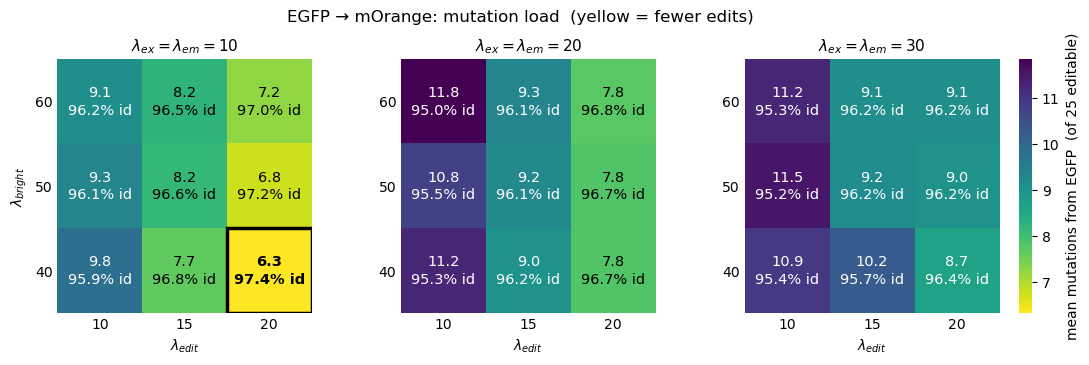

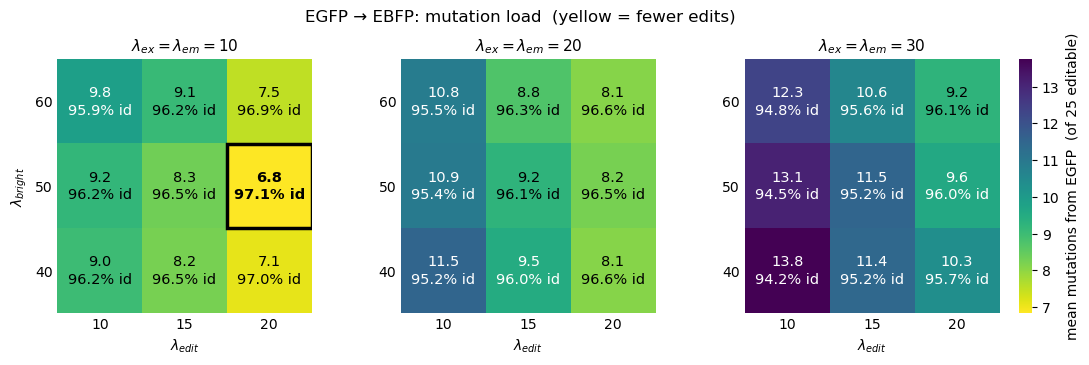

In [3]:
for tgt in TARGETS:
    fig = heatmaps([("n_mut", "mean mutations from EGFP  (of 25 editable)", "low")], tgt,
                   annot={"n_mut": lambda r, v: f"{v:.1f}\n{r.ident:.1f}% id"},
                   fname=f"sweep_mutations_{tgt}.png")
    fig.suptitle(f"EGFP → {tgt}: mutation load  (yellow = fewer edits)", y=1.03, fontsize=12)

## 2. Distance to the target peaks

Three rows, all in nm and all surrogate-predicted:

- **`|Δex|`** = mean `|pred_ex − target_ex|` — excitation only (EGFP 488 → 548 mOrange / 380 EBFP nm).
- **`|Δem|`** = mean `|pred_em − target_em|` — emission only (EGFP 507 → 562 mOrange / 440 EBFP nm).
- **`peak_err`** = `½(|Δex| + |Δem|)`, the quantity the search actually minimizes, with the **best
  single design** in the cell annotated underneath the cell mean.

Separating the two peaks matters because they are not equally reachable: the guided score weights them
independently (`λ_ex`, `λ_em`, equal throughout this sweep), but a chromophore-pocket edit typically
moves both together, so a cell can shrink one gap while stalling on the other. Anything above the
scaffold's own error means the edits made the spectrum *worse* than doing nothing.

saved /home/ubuntu/spectrum-to-fp-design/design-campaign-EGFP/lambda_sweep/figures/sweep_peak_error_mOrange.png


saved /home/ubuntu/spectrum-to-fp-design/design-campaign-EGFP/lambda_sweep/figures/sweep_peak_error_EBFP.png


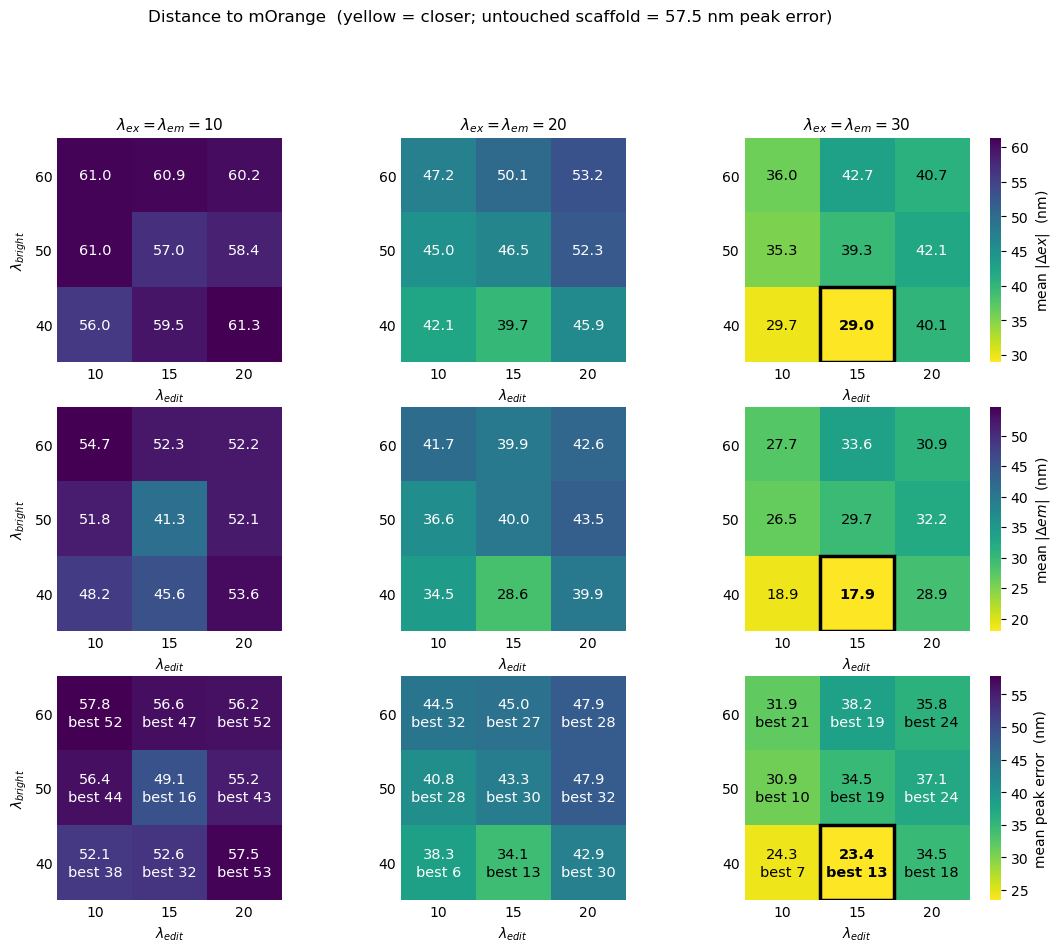

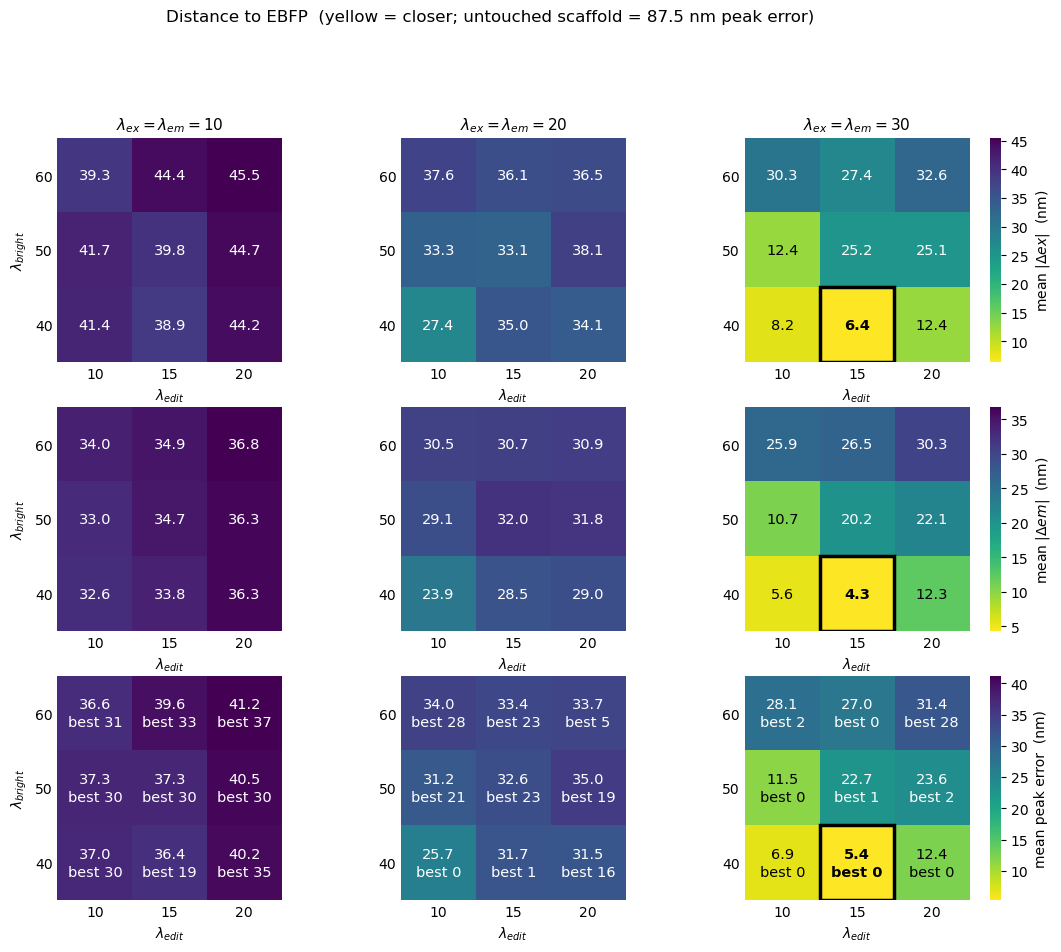

In [4]:
for tgt in TARGETS:
    fig = heatmaps([("d_ex", r"mean $|\Delta ex|$  (nm)", "low"),
                    ("d_em", r"mean $|\Delta em|$  (nm)", "low"),
                    ("peak_mean", "mean peak error  (nm)", "low")], tgt,
                   annot={"peak_mean": lambda r, v: f"{v:.1f}\nbest {r.peak_best:.0f}"},
                   fname=f"sweep_peak_error_{tgt}.png")
    fig.suptitle(f"Distance to {tgt}  (yellow = closer; untouched scaffold = {SCAF[tgt]:.1f} nm "
                 "peak error)", y=1.01, fontsize=12)

## 3. The two screening gates, and how many designs clear both

Colour is the **fraction** of the 12 designs that pass; the annotation gives the **count** as well,
since 12 trials makes single designs worth 8 percentage points.

- **ID** — 1-NN distance into the 40k GFP-DMS manifold within that set's own p99. This is a
  *trustworthiness* gate, not a quality one: it says the brightness classifier is interpolating rather
  than extrapolating on this sequence.
- **bright** — `cnn-max-d2` logit > 0.
- **ID and bright** — both at once. This is the number that matters, because a bright call on an
  out-of-distribution sequence is not evidence of anything. It is the pool a wet-lab shortlist is
  drawn from, so a cell with a low count is expensive to use regardless of how good its peaks look.

A cell can score well on brightness precisely *because* it barely edited the scaffold (EGFP is bright,
so staying near it is an easy way to keep the classifier happy) — which is why the mutation and peak
figures have to be read alongside this one.

saved /home/ubuntu/spectrum-to-fp-design/design-campaign-EGFP/lambda_sweep/figures/sweep_gates_mOrange.png


saved /home/ubuntu/spectrum-to-fp-design/design-campaign-EGFP/lambda_sweep/figures/sweep_gates_EBFP.png


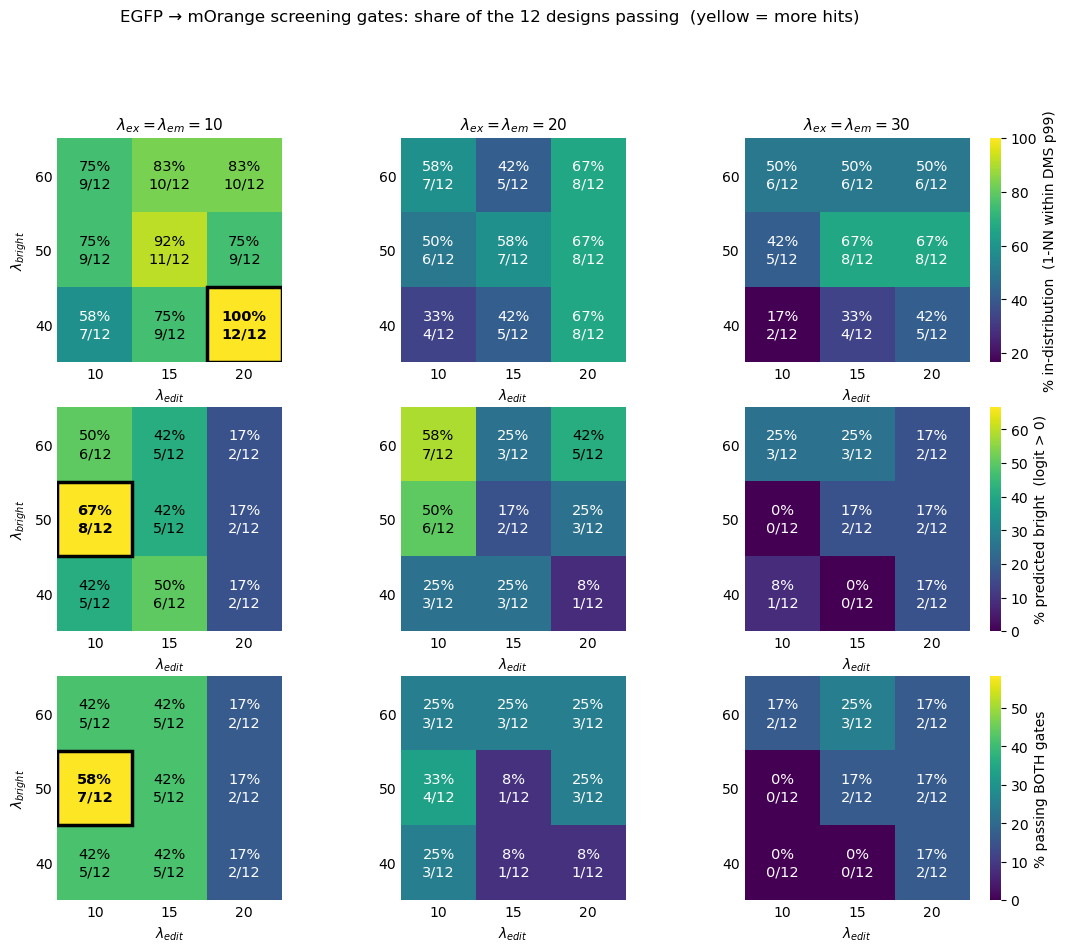

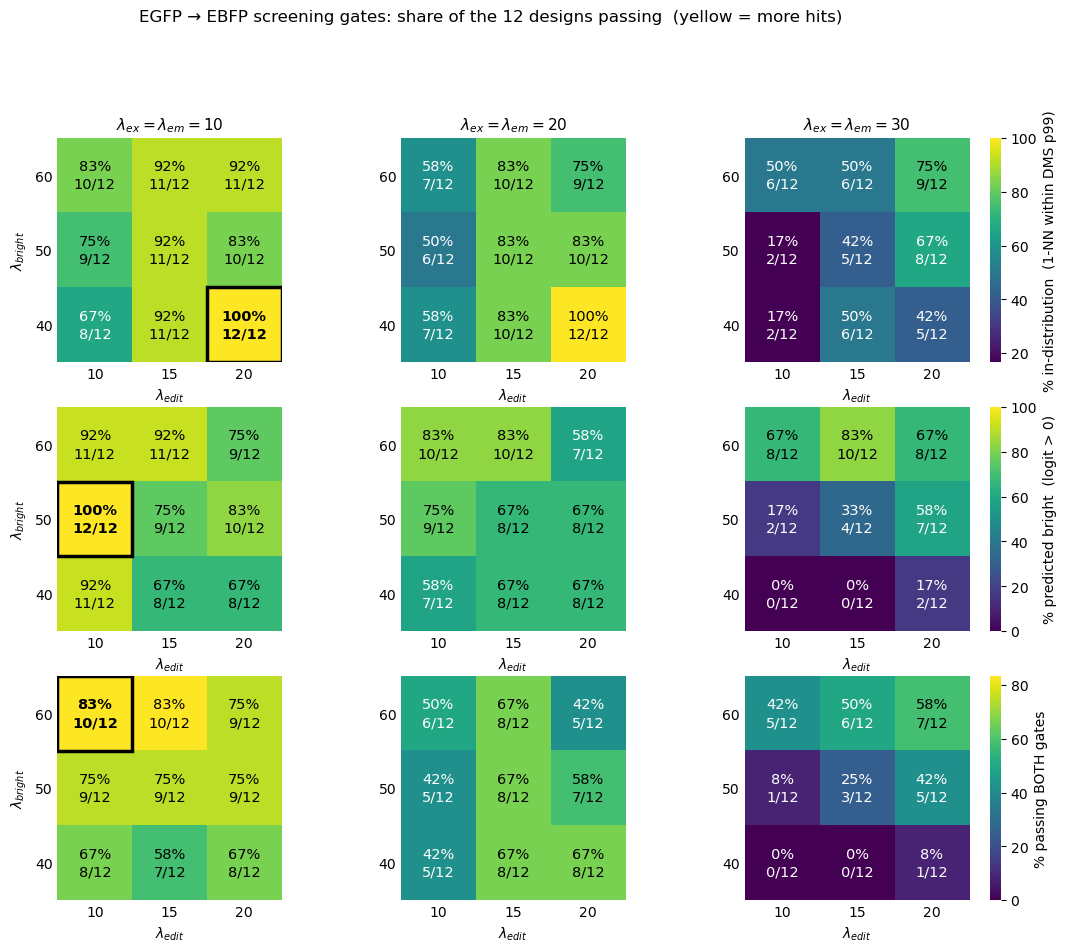

In [5]:
def frac_annot(count_col):
    return lambda r, v: f"{v:.0f}%\n{int(getattr(r, count_col))}/{int(r.n)}"


for tgt in TARGETS:
    fig = heatmaps([("pct_id", "% in-distribution  (1-NN within DMS p99)", "high"),
                    ("pct_bright", "% predicted bright  (logit > 0)", "high"),
                    ("pct_both", "% passing BOTH gates", "high")], tgt,
                   annot={"pct_id": frac_annot("n_id"), "pct_bright": frac_annot("n_bright"),
                          "pct_both": frac_annot("n_both")},
                   fname=f"sweep_gates_{tgt}.png")
    fig.suptitle(f"EGFP → {tgt} screening gates: share of the 12 designs passing  "
                 "(yellow = more hits)", y=1.01, fontsize=12)

## 4. The trade-off, design by design

The heatmaps above are cell averages at equal depth. These two figures instead show the **full design
pool**: every iteration (`round >= 1`) of every trial each run holds, deduped by sequence — the same
pool `make_shortlist_case.py` draws a shortlist from. The first plots each **individual design** on the
plane the choice actually lives on, **mutation load against peak error**, coloured by which screening
gates it passed. Down-and-left is better on both objectives at once, and the dotted horizontal line is
the untouched scaffold's error, so anything above it did spectral harm.

> **Pools are unequal here, on purpose.** Three cells were run 24–96 trials deep before this sweep
> existed, against 12 for the rest, and best-of-pool improves with pool size — the deepest cell holds
> ~287 designs versus ~36. So these figures answer "what designs are in hand", while the heatmaps
> answer "which setting is better per trial". Do not read a deep cell's low frontier point as evidence
> that its λs are superior.

Two step lines make the cost of the screen explicit:

- the **grey frontier** over *all* designs — the best accuracy achievable at each mutation budget;
- the **green frontier** over only the designs that clear **ID + bright** — the best accuracy you can
  actually take to the bench.

The vertical gap between them is what the brightness/in-distribution screen costs in nm. Averages hide
this: a cell whose mean error is mediocre can still contain the single best gate-passing design, and
that design is what a shortlist would draw.

Mutation counts are integers, so x is jittered by ±0.28 to keep coincident designs visible.

The second figure aggregates the same pool back to **one point per setting**, which is the view for
choosing λs rather than choosing designs. The frontier runs over setting means, colour is the share of
that setting's pool clearing both gates, and **marker area scales with pool size** so the three deep
cells are visually distinguishable from the 12-trial ones.

saved /home/ubuntu/spectrum-to-fp-design/design-campaign-EGFP/lambda_sweep/figures/sweep_designs_gates.png
 mOrange: best design overall   6.2 nm | best gate-passing  23.7 nm | gate-passing 201/1351 (15%)
    EBFP: best design overall   0.1 nm | best gate-passing   7.9 nm | gate-passing 607/1251 (49%)

where the best gate-passing design of each target comes from:
   mOrange: 23.7 nm | lam_p=30 lam_b=60 lam_e=10 | trial 2 round 3 of a 12-trial run | 11 mutations, logit +0.84
      EBFP: 7.9 nm | lam_p=20 lam_b=60 lam_e=10 | trial 78 round 3 of a 96-trial run | 9 mutations, logit +2.21


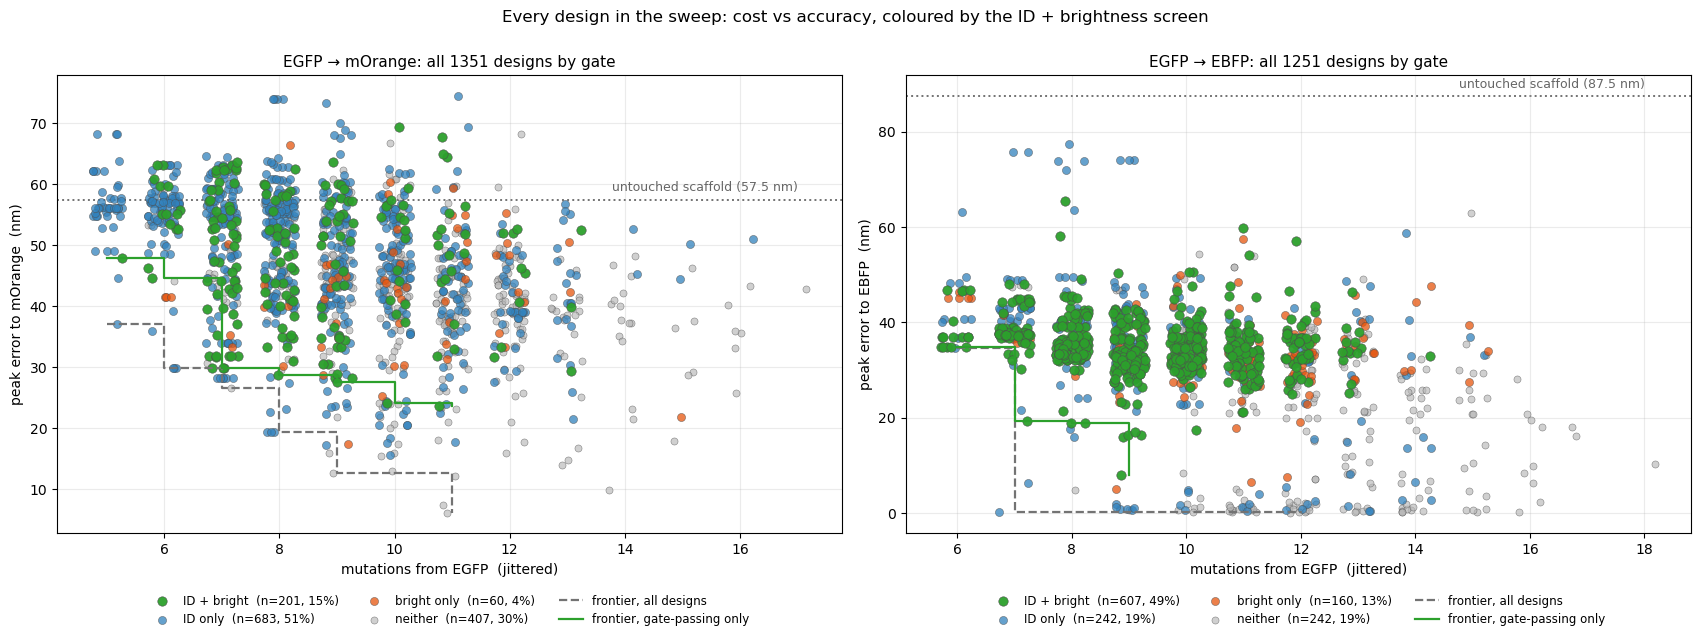

In [6]:
# Every individual design in the sweep -- all 27 settings, every iteration (round >= 1) of every
# trial, deduped by sequence -- coloured by which screening gates it passed. This is the pool a
# shortlist draws from, so pools are unequal: the three imported cells hold 24-96 trials.
GATE_STYLE = {                     # label: (colour, size, alpha, z)
    "ID + bright":  ("#2ca02c", 46, 0.95, 5),
    "ID only":      ("#3182bd", 34, 0.75, 4),
    "bright only":  ("#e6550d", 34, 0.75, 4),
    "neither":      ("0.72",    26, 0.65, 3),
}


def design_pareto(T, x="n_mut", y="peak_err"):
    """Non-dominated designs on (mutations, peak error), both minimized -- as a step frontier."""
    best, pts = np.inf, []
    for _, r in T.sort_values([x, y]).iterrows():
        if r[y] < best:
            best = r[y]; pts.append((r[x], r[y]))
    return np.array(pts) if pts else np.empty((0, 2))


rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(TARGETS), figsize=(8.6 * len(TARGETS), 6.4), squeeze=False)
for ax, tgt in zip(axes[0], TARGETS):
    T = D[D.target == tgt]
    for label, (colour, size, alpha, z) in GATE_STYLE.items():
        g = T[T.gate == label]
        # mutation counts are integers, so jitter x to keep overlapping designs visible
        ax.scatter(g.n_mut + rng.uniform(-0.28, 0.28, len(g)), g.peak_err, s=size, c=colour,
                   alpha=alpha, linewidth=0.4, edgecolor="0.3", zorder=z,
                   label=f"{label}  (n={len(g)}, {100 * len(g) / len(T):.0f}%)")
    for sub, colour, style, lab in ((T, "0.45", "--", "frontier, all designs"),
                                    (T[T.gate == "ID + bright"], "#2ca02c", "-",
                                     "frontier, gate-passing only")):
        P = design_pareto(sub)
        if len(P):
            ax.step(P[:, 0], P[:, 1], where="post", c=colour, ls=style, lw=1.6, zorder=6, label=lab)
    ax.axhline(SCAF[tgt], ls=":", c="0.45", lw=1.4, zorder=1)
    ax.text(T.n_mut.max(), SCAF[tgt] + 1.0, f"untouched scaffold ({SCAF[tgt]:.1f} nm)",
            va="bottom", ha="right", fontsize=9, color="0.4")
    ax.set_xlabel("mutations from EGFP  (jittered)")
    ax.set_ylabel(f"peak error to {tgt}  (nm)")
    ax.set_title(f"EGFP → {tgt}: all {len(T)} designs by gate", fontsize=11)
    # legend below the axes: the top-right corner is where the scaffold annotation lives
    ax.legend(frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.11), ncol=3)
    ax.grid(alpha=0.25, zorder=0)
fig.suptitle("Every design in the sweep: cost vs accuracy, coloured by the ID + brightness screen",
             y=1.0, fontsize=12)
fig.tight_layout()
fig.savefig(FIGDIR / "sweep_designs_gates.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "sweep_designs_gates.png")

# how much accuracy does insisting on both gates cost, at the level of single designs?
for tgt in TARGETS:
    T = D[D.target == tgt]
    g = T[T.gate == "ID + bright"]
    print(f"{tgt:>8}: best design overall {T.peak_err.min():5.1f} nm | "
          f"best gate-passing {g.peak_err.min():5.1f} nm | "
          f"gate-passing {len(g)}/{len(T)} ({100 * len(g) / len(T):.0f}%)")

# best-of-pool depends on pool size, so name the source of each best design and how deep it was
print("\nwhere the best gate-passing design of each target comes from:")
for tgt in TARGETS:
    g = D[(D.target == tgt) & (D.gate == "ID + bright")]
    r = g.loc[g.peak_err.idxmin()]
    print(f"  {tgt:>8}: {r.peak_err:.1f} nm | lam_p={r.lam_p:g} lam_b={r.lam_b:g} lam_e={r.lam_e:g} "
          f"| trial {int(r.trial)} round {int(r['round'])} of a {int(r.trials_avail)}-trial run "
          f"| {int(r.n_mut)} mutations, logit {r.logit:+.2f}")

saved /home/ubuntu/spectrum-to-fp-design/design-campaign-EGFP/lambda_sweep/figures/sweep_tradeoff.png


,target,lam_p,lam_b,lam_e,n,n_mut,peak_mean,peak_best,n_id,n_bright,n_both
29,mOrange,10.0,40.0,20.0,34,6.0,56.9,39.3,34,2,2
32,mOrange,10.0,50.0,20.0,36,6.6,56.2,43.4,29,3,3
38,mOrange,20.0,40.0,20.0,34,7.4,46.9,29.9,26,1,1
37,mOrange,20.0,40.0,15.0,35,8.7,40.2,12.9,15,4,1
47,mOrange,30.0,40.0,20.0,36,9.0,36.8,15.5,14,2,2
49,mOrange,30.0,50.0,15.0,36,9.7,36.2,17.4,19,2,2
46,mOrange,30.0,40.0,15.0,36,10.2,30.9,12.8,14,0,0
5,EBFP,10.0,50.0,20.0,35,7.4,41.6,30.2,29,25,22
1,EBFP,10.0,40.0,15.0,35,8.1,39.5,19.4,33,24,22
11,EBFP,20.0,40.0,20.0,36,8.2,34.1,16.0,33,20,18


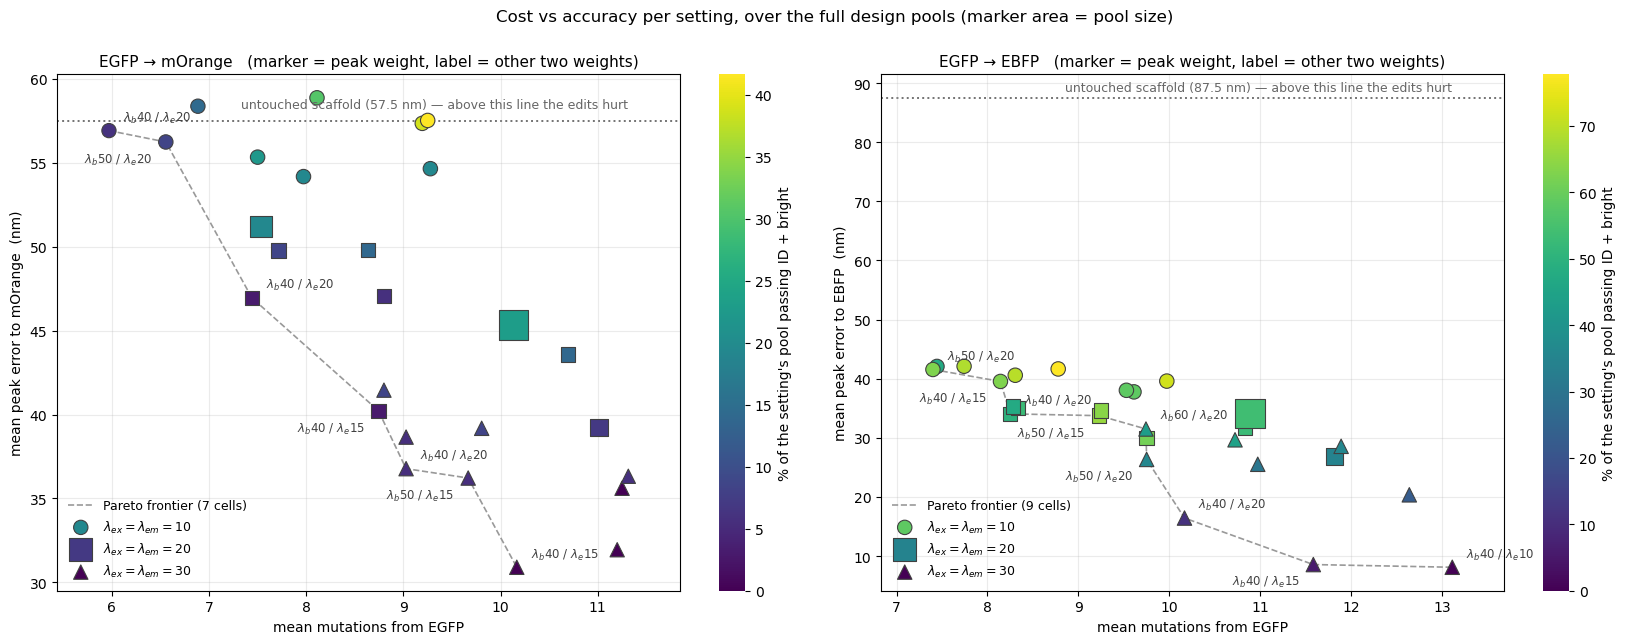

In [7]:
# The same designs aggregated back to ONE POINT PER SETTING: cell means over the full pool
# (rounds >= 1, every trial), so this is the setting-level view of the scatter above. Marker area
# scales with pool size, since the three imported cells are 2-8x deeper than the rest.
MARK = {lp: m for lp, m in zip(LP, ["o", "s", "^"])}
A = (D.assign(pass_both=D.is_id & D.is_bright)
      .groupby(["target", "lam_p", "lam_b", "lam_e"])
      .agg(n=("peak_err", "size"), n_mut=("n_mut", "mean"), peak_mean=("peak_err", "mean"),
           peak_best=("peak_err", "min"), n_id=("is_id", "sum"), n_bright=("is_bright", "sum"),
           n_both=("pass_both", "sum"), logit=("logit", "mean"))
      .reset_index())
A["pct_both"] = 100 * A.n_both / A.n


def pareto(T):
    """Settings that no other setting beats on BOTH mean mutation count and mean peak error."""
    keep = [not ((T.n_mut <= r.n_mut) & (T.peak_mean <= r.peak_mean)
                 & ((T.n_mut < r.n_mut) | (T.peak_mean < r.peak_mean))).any() for r in T.itertuples()]
    return T[keep].sort_values("n_mut")


fig, axes = plt.subplots(1, len(TARGETS), figsize=(8.4 * len(TARGETS), 6.4), squeeze=False)
fronts = {}
for ax, tgt in zip(axes[0], TARGETS):
    T = A[A.target == tgt]
    fronts[tgt] = front = pareto(T)
    ax.plot(front.n_mut, front.peak_mean, ls="--", c="0.6", lw=1.2, zorder=2,
            label=f"Pareto frontier ({len(front)} cells)")
    for lp in LP:
        g = T[T.lam_p == lp]
        sc = ax.scatter(g.n_mut, g.peak_mean, c=g.pct_both, cmap="viridis", vmin=0,
                        vmax=max(T.pct_both.max(), 1), marker=MARK[lp],
                        s=60 + 380 * g.n / T.n.max(), edgecolor="0.25", linewidth=0.8, zorder=3,
                        label=rf"$\lambda_{{ex}}=\lambda_{{em}}={lp:g}$")
    for i, r in enumerate(front.itertuples()):   # alternate label side so neighbours don't collide
        up = i % 2 == 0
        ax.annotate(rf"$\lambda_b${r.lam_b:g} / $\lambda_e${r.lam_e:g}", (r.n_mut, r.peak_mean),
                    textcoords="offset points", xytext=(10, 7) if up else (-10, -15),
                    ha="left" if up else "right", fontsize=8.5, color="0.25")
    ax.axhline(SCAF[tgt], ls=":", c="0.45", lw=1.4, zorder=1)
    ax.text(T.n_mut.max(), SCAF[tgt] + 0.6,
            f"untouched scaffold ({SCAF[tgt]:.1f} nm) — above this line the edits hurt",
            va="bottom", ha="right", fontsize=9, color="0.4")
    ax.set_xlabel("mean mutations from EGFP")
    ax.set_ylabel(f"mean peak error to {tgt}  (nm)")
    ax.set_title(f"EGFP → {tgt}   (marker = peak weight, label = other two weights)", fontsize=11)
    ax.legend(frameon=False, loc="lower left", fontsize=9)
    ax.grid(alpha=0.25, zorder=0)
    ax.margins(x=0.10)                      # room for the frontier labels at the panel edges
    fig.colorbar(sc, ax=ax, label="% of the setting's pool passing ID + bright"
                 ).outline.set_visible(False)
fig.suptitle("Cost vs accuracy per setting, over the full design pools "
             "(marker area = pool size)", y=1.0, fontsize=12)
fig.tight_layout()
fig.savefig(FIGDIR / "sweep_tradeoff.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "sweep_tradeoff.png")
pd.concat(fronts.values())[["target", "lam_p", "lam_b", "lam_e", "n", "n_mut", "peak_mean",
                            "peak_best", "n_id", "n_bright", "n_both"]].round(1)

## 5. What each λ does on its own, and the leaderboard

**Marginals** average over the other two axes, per target, which is the cleanest read on each weight's
direction of effect (each row pools 9 cells / 108 designs). With only 12 trials per cell, single-cell
differences of a few nm are noise; the marginals are what to trust for "which way does this knob turn".
Where the two targets disagree on a knob's direction, that is a real finding about the targets, not an
artifact — a near-in-sequence target and a far one are not reached the same way.

**Leaderboards** rank each target's cells by designs clearing both gates, breaking ties on peak error —
i.e. "most usable designs, closest to target". Sort differently if the priority is different; nothing
here picks a winner on your behalf.

In [8]:
AGG = dict(cells=("n", "size"), designs=("n", "sum"), n_mut=("n_mut", "mean"),
           d_ex=("d_ex", "mean"), d_em=("d_em", "mean"), peak_mean=("peak_mean", "mean"),
           pct_id=("pct_id", "mean"), logit=("logit", "mean"),
           pct_bright=("pct_bright", "mean"), pct_both=("pct_both", "mean"))
for axis, name in (("lam_p", "lam_ex = lam_em"), ("lam_b", "lam_bright"), ("lam_e", "lam_edit")):
    print(f"\n===== marginal: {name} (mean over the other two axes, per target) =====")
    print(S.groupby(["target", axis]).agg(**AGG).round(1).to_string())

LB_COLS = ["lam_p", "lam_b", "lam_e", "n_mut", "ident", "d_ex", "d_em", "peak_mean", "peak_best",
           "n_id", "n_bright", "n_both", "logit"]
for tgt in TARGETS:
    print(f"\n\n===== {tgt} leaderboard: most designs passing both gates, then closest peaks =====")
    board = S[S.target == tgt].sort_values(["n_both", "peak_mean"], ascending=[False, True])
    print(board[LB_COLS].round(1).to_string(index=False))


===== marginal: lam_ex = lam_em (mean over the other two axes, per target) =====
               cells  designs  n_mut  d_ex  d_em  peak_mean  pct_id  logit  pct_bright  pct_both
target  lam_p                                                                                   
EBFP    10.0       9      108    8.3  42.2  34.7       38.5    86.1    1.9        82.4      73.1
        20.0       9      108    9.5  34.6  29.6       32.1    75.0    0.9        69.4      55.6
        30.0       9      108   11.3  20.0  17.5       18.8    45.4   -1.8        38.0      25.9
mOrange 10.0       9      108    8.1  59.5  50.2       54.8    79.6   -0.5        38.0      35.2
        20.0       9      108    9.4  46.9  38.6       42.7    53.7   -1.6        30.6      20.4
        30.0       9      108    9.9  37.2  27.4       32.3    46.3   -2.4        13.9      12.0

===== marginal: lam_bright (mean over the other two axes, per target) =====
               cells  designs  n_mut  d_ex  d_em  peak_mean  pct_